<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-257-Machine-Learning/blob/main/W3S1_SU26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CMPE-257, Machine Learning, Summer 2026
## Week 3: Linear Regression and Classification

In this workbook, you will be exporing some linear models:

- linear and multilinear regressions
- classification with logistic regression
- classification with naive Bayes

In [1]:
# YOUR NAME: <Meenakshi Rajpurohit>

In [4]:
# loads required modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

## PART 1: Linear and Multilinear Regressions

In [5]:
# The following function is used to display some linear regression scores of interest for regression models
# generated with the statsmodels module

def report_stats(rslt,pflag=True,rflag=False):
    tdx = {}
    lbls1 = ['coefficient','standard error','t-statistic','p-value']
    scrs1 = [rslt.params,rslt.bse,rslt.tvalues,rslt.pvalues]
    if pflag: display(pd.DataFrame(scrs1,index=lbls1).T)
    for k,v in zip(lbls1,scrs1): tdx[k]=v
    lbls2 = ['Residual SE','R-squared','Adjusted Rsq','F-statistic']
    scrs2 = [np.sqrt(rslt.ssr/(rslt.nobs-rslt.params.shape[0])),rslt.rsquared,rslt.rsquared_adj,rslt.fvalue]
    if pflag: display(pd.DataFrame(scrs2,index=lbls2,columns=['Model Scores']).T)
    for k,v in zip(lbls2,scrs2): tdx[k]=v
    if rflag: return tdx

In [6]:
# Exercise #1: consider the three-point regression exercise conducted in class, which is reproduced in this cell

# Creates a dataframe containing the three point in-sample dataset {p1:(1.0,4.50), p2:(2.0,2.5), p3:(3.0,2.0)}
# and adds a constant variable xo which will be associated to the constant term parameter (i.e. the intercept)
data = pd.DataFrame([[1,1,4.5],[1,2,2.5],[1,3,2]],columns=['xo','x1','y'])
#display(data)

# Performs the linear regression and prints the main scores and statistics
reg = sm.OLS(data['y'],data[['xo','x1']]).fit()
report_stats(reg)

,coefficient,standard error,t-statistic,p-value
xo,5.50,0.935414,5.879747,0.107247
x1,-1.25,0.433013,-2.886751,0.212296


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,0.612372,0.892857,0.785714,8.333333


In [ ]:
# How results in exercises #1 compare to the results obtained in class?
# <They match exactly, the slide's fractions are the same numbers statsmodels prints. The notebook adds what in the class didn't compute, Residual SE etc  >

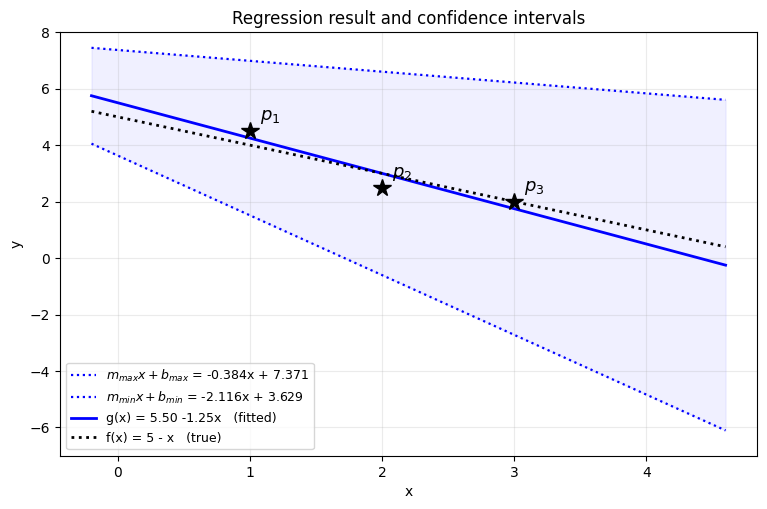

In [8]:
# Exercise #1 (continuation): generate a plot including the following elements: the three in-sample data points,
# the obtained regression line g(x), the actual generating function f(x) = 5 - x, and the two boundary lines that
# can be derived from the confidence intervals b+/-2SE(b) and m+/-2SE(m)

# add your code here...

import matplotlib.pyplot as plt

# --- coefficients and their standard errors from the fitted model -------------
b,  m  = reg.params['xo'], reg.params['x1']      #  b = 5.50 ,  m = -1.25
sb, sm = reg.bse['xo'],    reg.bse['x1']         # SE = 0.9354 , 0.4330

# --- 95%-style confidence intervals:  b +/- 2SE(b)  and  m +/- 2SE(m) ---------
b_min, b_max = b - 2*sb, b + 2*sb                # [ 3.629 ,  7.371 ]
m_min, m_max = m - 2*sm, m + 2*sm                # [-2.116 , -0.384 ]

# --- the two boundary lines --------------------------------------------------
# for x > 0, (b + m x) is increasing in both b and m, so the extremes over the
# CI rectangle are:  upper = m_max x + b_max ,  lower = m_min x + b_min
xs  = np.linspace(-0.2, 4.6, 200)
upper = m_max*xs + b_max
lower = m_min*xs + b_min

fig, ax = plt.subplots(figsize=(9,5.5))
ax.fill_between(xs, lower, upper, color='blue', alpha=0.06)
ax.plot(xs, upper, 'b:', lw=1.6, label=f'$m_{{max}}x + b_{{max}}$ = {m_max:.3f}x + {b_max:.3f}')
ax.plot(xs, lower, 'b:', lw=1.6, label=f'$m_{{min}}x + b_{{min}}$ = {m_min:.3f}x + {b_min:.3f}')
ax.plot(xs, b + m*xs, 'b-', lw=2, label=f'g(x) = {b:.2f} {m:+.2f}x   (fitted)')
ax.plot(xs, 5 - xs,   'k:', lw=2, label='f(x) = 5 - x   (true)')

ax.plot(data['x1'], data['y'], 'k*', ms=13, zorder=5)
for i, (xx, yy) in enumerate(zip(data['x1'], data['y']), 1):
    ax.annotate(f'$p_{i}$', (xx, yy), textcoords='offset points', xytext=(7,8), fontsize=13)

ax.set_ylim(-7, 8); ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Regression result and confidence intervals')
ax.legend(fontsize=9, loc='lower left'); ax.grid(alpha=0.25)
plt.show()


In [ ]:
# How your generated plot compares to the one presented in class?
# <It matches. Same four elements, same numbers: * the 3 in-sample points p1(1,4.5), p2(2,2.5), p3(3,2), fitted line   g(x) = 5.50 - 1.25 x, true function f(x) = 5 - x. >

In [13]:
import statsmodels.api as sm
# Exercise #2: download the file "Advertising.csv" from the book website, use the following link
# "https://www.statlearning.com/s/Advertising.csv". This dataset contains 200 data points comprising
# three predictor varaibles (TV, radio, newspaper) and one target variable (sales).

# load the dataset...
data = pd.read_csv('/content/Advertising.csv')

# and add a constant variable (intercept)
data['intercept'] = [1.0 for x in range(data.shape[0])]

# compute a linear regression on the predictor variable TV and show the stats
reg_tv = sm.OLS(data['sales'],data[['intercept','TV']]).fit()
report_stats(reg_tv)

,coefficient,standard error,t-statistic,p-value
intercept,7.032594,0.457843,15.360275,1.406300e-35
TV,0.047537,0.002691,17.667626,1.467390e-42


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,3.258656,0.611875,0.609915,312.144994


In [ ]:
# How these results compare to the ones in the book (Tables 3.1 and 3.2 in Section 3.1)?
# <They match exactly, to every digit the book displays.>

In [14]:
# Exercise #2 (continuation): compute a linear regression on the predictor variable radio and show the stats

# add your code here...
reg_radio = sm.OLS(data['sales'], data[['intercept','radio']]).fit()
report_stats(reg_radio)


,coefficient,standard error,t-statistic,p-value
intercept,9.311638,0.562900,16.542245,3.561071e-39
radio,0.202496,0.020411,9.920765,4.354966e-19


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,4.274944,0.332032,0.328659,98.421588


In [ ]:
# How these results compare to the ones in the book (Table 3.3 in Section 3.1)?
# <They match the book's radio panel exactly (9.312 / 0.203, both highly significant). Radio is a weaker predictor than TV, though: R^2 = 0.33 vs 0.61, with a larger RSE.  >

In [15]:
# Exercise #2 (continuation): compute a linear regression on the predictor variable newspaper and show the stats

# add your code here...
reg_news = sm.OLS(data['sales'], data[['intercept','newspaper']]).fit()
report_stats(reg_news)


,coefficient,standard error,t-statistic,p-value
intercept,12.351407,0.621420,19.876096,4.713507e-49
newspaper,0.054693,0.016576,3.299591,1.148196e-03


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,5.09248,0.05212,0.047333,10.887299


In [ ]:
# How these results compare to the ones in the book (Table 3.3 in Section 3.1)?
# <They match the book's newspaper panel exactly (12.351 / 0.055, t = 19.88 and 3.30). the book prints "< 0.0001" for newspaper, but the true p-value is
# 0.00115 significant, though nowhere near as decisively as TV or radio. >

In [16]:
# Exercise #3: compute a mutilinear regression on the three predictor variables (TV, radio, and newspaper)
# and show the resulting stats.

# add your code here...
reg_all = sm.OLS(data['sales'], data[['intercept','TV','radio','newspaper']]).fit()
report_stats(reg_all)



,coefficient,standard error,t-statistic,p-value
intercept,2.938889,0.311908,9.422288,1.267295e-17
TV,0.045765,0.001395,32.808624,1.509960e-81
radio,0.188530,0.008611,21.893496,1.505339e-54
newspaper,-0.001037,0.005871,-0.176715,8.599151e-01


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,1.68551,0.897211,0.895637,570.270704


In [ ]:
# How these results compare to the ones in the book (Table 3.4 in Section 3.2)? And how they compare to the
# single variable regressions from exercise #2? (make sure you include comments on R-squared and p-values)
# <Exact match with Table 3.4. Versus the simple regressions: TV and radio keep their coefficients and gain precision, but newspaper collapses its p-value goes from significant to ~0.86 (and the sign flips). Newspaper spend correlates with radio spend, so alone it was just a proxy for radio. R^2 rises to ~0.90 (from 0.61 / 0.33 / 0.05) with a much smaller RSE, though adding newspaper contributes essentially nothing R^2 never falls when a predictor is added, so Adj R^2 and the p-values are what tell you whether a variable actually earns its place.  >

In [17]:
# Exercise #3 (continuation): compute the corresponding correlation coefficients among the different pairs
# of predictor variables, and between the predictor and target variable as well.

# add your code here...
corr = data[['TV','radio','newspaper','sales']].corr()
display(corr)


,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


In [ ]:
# How these results compare to the ones in the book (Table 3.5 in Section 3.2)? What these results are telling?
# <Exact match with Table 3.5 (the book only prints the upper triangle, the matrix being symmetric). The key entry is corr(radio, newspaper) = 0.354 the only sizeable correlation among predictors: newspaper spend tracks radio spend, so alone it acts as a proxy for radio, which explains its spurious significance in Ex.#2 and its collapse once radio enters the model. TV and radio are nearly uncorrelated, hence their coefficients barely moved between the simple and multiple fits. >

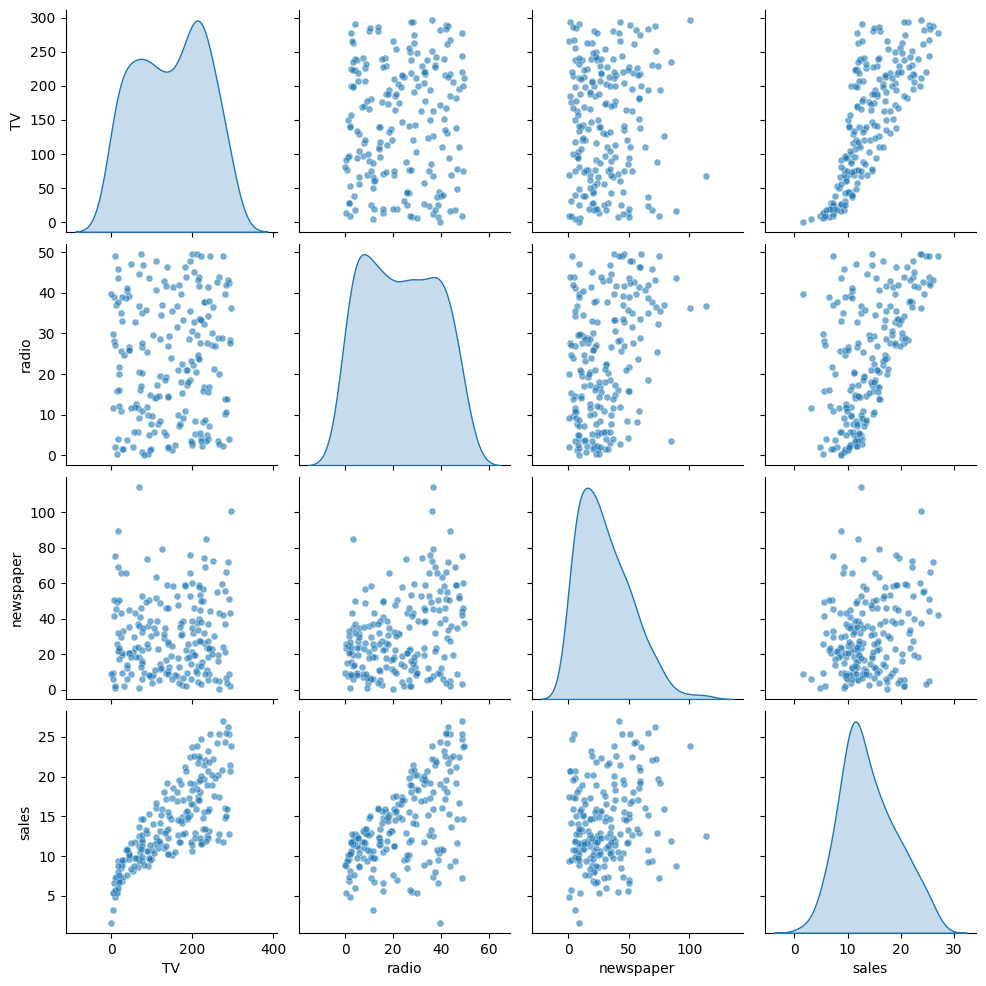

In [18]:
# Exercise #3 (continuation): use function pairplot in the seaborn library to generte the scatterplot matrix for
# the predictor variables (TV, radio, and newspaper) and target variable.

# add your code here...
sns.pairplot(data[['TV','radio','newspaper','sales']], diag_kind='kde',
             plot_kws={'alpha':0.6, 's':25, 'edgecolor':'w', 'linewidth':0.4})
plt.show()



In [ ]:
# Any observations about your last results from exercises #3?
# <The sales row confirms the ranking: a strong (but visibly CURVED) trend against TV, a noisier one against radio, and essentially a shapeless cloud against newspaper. The TV panel also fans out as the budget grows non-linearity plus non-constant variance, which is exactly what motivates the transformations and interaction terms in Section 3.3.  >

In [19]:
# Exercise #4: explore the interaction effect between the two predictor variebles TV and radio. First, create
# a new variable "TV x radio" by multiplying these two variables. Then, compute mutilinear regressions on the
# two variables and on the two variables plus the newly created one. Print the corresponding stat reports.

# add your code here...
# create the interaction variable
data['TV x radio'] = data['TV'] * data['radio']

# model without interaction
reg_2 = sm.OLS(data['sales'], data[['intercept','TV','radio']]).fit()
report_stats(reg_2)

# model with interaction
reg_int = sm.OLS(data['sales'], data[['intercept','TV','radio','TV x radio']]).fit()
report_stats(reg_int)


,coefficient,standard error,t-statistic,p-value
intercept,2.921100,0.29449,9.919193,4.565557e-19
TV,0.045755,0.00139,32.908708,5.436980e-82
radio,0.187994,0.00804,23.382446,9.776972e-59


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,1.681361,0.897194,0.896151,859.617718


,coefficient,standard error,t-statistic,p-value
intercept,6.750220,0.247871,27.232755,1.541461e-68
TV,0.019101,0.001504,12.698953,2.363605e-27
radio,0.028860,0.008905,3.240815,1.400461e-03
TV x radio,0.001086,0.000052,20.726564,2.757681e-51


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,0.943515,0.967791,0.967298,1963.056876


In [ ]:
# How these results compare to the ones in the book (Table 3.9 in Section 3.3)? What can be said about the
# interaction effect between the two predictor variables TV and Radio?
# <Exact match with Table 3.9. The interaction is highly significant (t = 20.73): R^2 rises from 0.897 to 0.968 it captures ~68% of the variance the additive model left unexplained and RSE nearly halves. This is SYNERGY: the effective TV slope becomes 0.0191 + 0.0011*radio, so a dollar of TV buys much more when radio spend is high. Splitting the budget across both media beats concentrating it in one.>

In [20]:
# Exercise #5: explore a potential non-linear relationships between the predictor variable TV and the target
# variable sales. Suggestion: consider a reationship of the type Y ~ log(X). Then, compute the linear regression
# on the TV variable and the multilinear regression on the TV variable plus the newly created one. Print the
# corresponding stat reports.

# add your code here...
# create the log-transformed variable
data['log(TV)'] = np.log(data['TV'])

# linear regression on TV alone
reg_tv = sm.OLS(data['sales'], data[['intercept','TV']]).fit()
report_stats(reg_tv)

# multilinear regression on TV plus log(TV)
reg_log = sm.OLS(data['sales'], data[['intercept','TV','log(TV)']]).fit()
report_stats(reg_log)


,coefficient,standard error,t-statistic,p-value
intercept,7.032594,0.457843,15.360275,1.406300e-35
TV,0.047537,0.002691,17.667626,1.467390e-42


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,3.258656,0.611875,0.609915,312.144994


,coefficient,standard error,t-statistic,p-value
intercept,2.629151,1.606838,1.636227,1.033888e-01
TV,0.032968,0.005748,5.736013,3.606565e-08
log(TV),1.401023,0.490802,2.854560,4.770823e-03


,Residual SE,R-squared,Adjusted Rsq,F-statistic
Model Scores,3.201378,0.627291,0.623508,165.781534


In [ ]:
# What are your main conclusions from resulst in exercise #5?
# <The log term is significant (p = 0.005) and both R^2 and Adj R^2 improve, confirming the curvature seen in the pairplot: sales show diminishing returns to TV spend, which a straight line cannot capture. Still, the gain is modest next to the TV x radio interaction of Ex.#4 the non-linearity is real but second-order compared with the synergy between the two channels.  >

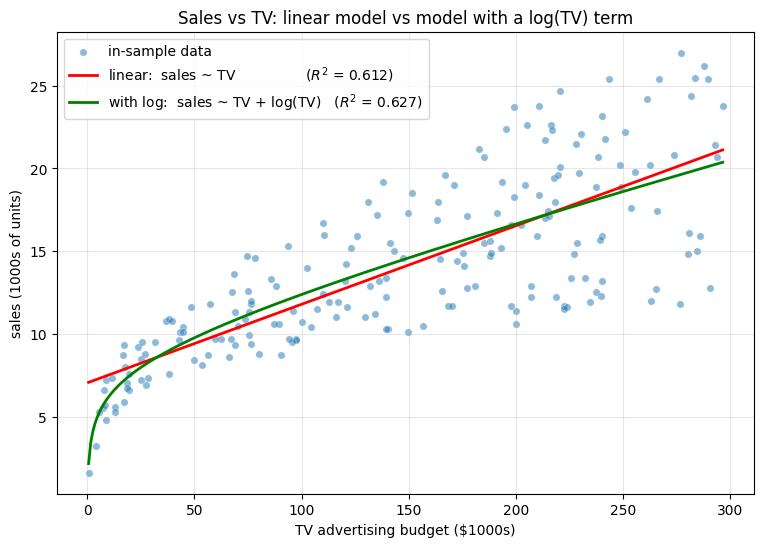

In [21]:
# Exercise #5 (continuation): generate plot displaying the in-sample data and the two regression
# models obtained in the previous step of exercise #5.

# add your code here...
# grid of TV values for plotting the fitted curves
xs   = np.linspace(data['TV'].min(), data['TV'].max(), 300)
grid = pd.DataFrame({'intercept': 1.0, 'TV': xs, 'log(TV)': np.log(xs)})

fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(data['TV'], data['sales'], alpha=0.5, s=28, edgecolor='w', linewidth=0.4,
           label='in-sample data')
ax.plot(xs, reg_tv.predict(grid[['intercept','TV']]), 'r-', lw=2,
        label='linear:  sales ~ TV                ($R^2$ = 0.612)')
ax.plot(xs, reg_log.predict(grid[['intercept','TV','log(TV)']]), 'g-', lw=2,
        label='with log:  sales ~ TV + log(TV)   ($R^2$ = 0.627)')

ax.set_xlabel('TV advertising budget ($1000s)')
ax.set_ylabel('sales (1000s of units)')
ax.set_title('Sales vs TV: linear model vs model with a log(TV) term')
ax.legend(); ax.grid(alpha=0.3)
plt.show()



In [ ]:
# What are your main observations?
# <The green curve bends the way the data do steep at small budgets, flattening at large ones while the straight line cannot; the two differ most at the low end, where the curvature lives, and nearly coincide elsewhere, hence the modest R^2 gain. The plot also exposes what neither model fixes: the vertical spread widens with TV (heteroscedasticity), and the wide scatter at high TV eminds us that TV alone still leaves ~37% of the variance unexplained.  >

## PART 2: Classification with Logistic Regression

In [22]:
# loads required modules
from tqdm import tqdm
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report

In [24]:
# Exercise #6: this cell includes python code to load a text dataset and train a logistic regression model
# on it. Inspect the different steps in the script and run the code

# Step 1: loads the experiemtal data collection "Books.csv"
books = pd.read_csv('/content/Books.csv')
#display(books)
# This dataset contains selected paragraphs from three different books:
# Pride and Prejudice by Jane Austen [eBook #1342 @ https://www.gutenberg.org/]
# Moby Dick; Or, The Whale by Herman Melville [eBook #2701 @ https://www.gutenberg.org/]
# Oliver Twist by Charles Dickens [eBook #730 @ https://www.gutenberg.org/]
# Three fields are provided: doc_id (composed of three parts: book id, chapter id and paragraph id), raw_text
# (the original paragraph contents) and tokenized_text (a tokenized version with punctuation marks removed)

# Step 2: adds an additional column conatining the book id only
books['targets'] = [x.split('-')[0] for x in books['doc_id']]
labels = sorted(books['targets'].drop_duplicates().values)

# Step 3: splits the data into in-sample (train) and out-of-sample (test) datasets, using 50% of the data for each
train,test = train_test_split(books[['tokenized_text','targets']],test_size=0.5)

# Step 4: uses the in-sample (train) data to train the vectorizer, which uses word counts as features to represent
# each paragraph in the dataset. Retains the 200 words with highest counts to be used as predictor variables.
trn_text = train['tokenized_text'].values
vectorizer = CountVectorizer(max_features = 200)
trn_feat = vectorizer.fit_transform(trn_text)

# Step 5: computes the corresponding feature vectors for the out-of-sample (test) portion of the data.
tst_text = test['tokenized_text'].values
tst_feat = vectorizer.transform(tst_text)

# Step 6: gets the target vectors for each portion of the dataset: in-sample and out-of-sample
trn_trgt = train['targets'].values
tst_trgt = test['targets'].values

# Step 7: trains a multilinear regression model
logreg = linear_model.LogisticRegression()
logreg.fit(trn_feat, trn_trgt)

# Step 8: applies the model to the in-sample dataset and computes confusion matrix and evaluation scores
trn_pdct = logreg.predict(trn_feat)
print('\nIn-sample data evaluation scores:\n')
scores_trn_lreg = classification_report(trn_trgt,trn_pdct)
print(scores_trn_lreg)

# Step 9: applies the model to the out-of-sample dataset and computes confusion matrix and evaluation scores
tst_pdct = logreg.predict(tst_feat)
print('\nOut-of-sample data evaluation scores:\n')
scores_tst_lreg = classification_report(tst_trgt,tst_pdct)
print(scores_tst_lreg)


In-sample data evaluation scores:

              precision    recall  f1-score   support

         000       0.95      0.95      0.95       626
         001       0.94      0.91      0.93       637
         002       0.93      0.95      0.94      1120

    accuracy                           0.94      2383
   macro avg       0.94      0.94      0.94      2383
weighted avg       0.94      0.94      0.94      2383


Out-of-sample data evaluation scores:

              precision    recall  f1-score   support

         000       0.90      0.84      0.87       616
         001       0.83      0.84      0.83       653
         002       0.86      0.89      0.87      1114

    accuracy                           0.86      2383
   macro avg       0.86      0.85      0.86      2383
weighted avg       0.86      0.86      0.86      2383



In [ ]:
# What are your main conclusions from the results obtained in exercise #6?
# <The model works well: 86% out-of-sample accuracy against a ~47% majority-class baseline. But note the GAP 0.94 in-sample vs 0.86 out-of-sample: the training score is optimistically biased since the model was fit on that data, so only the test score honestly estimates generalization (mild overfitting here). Striking too is that the 200 most frequent words are mostly function words with no topical content the classifier is picking up HOW each author writes, not what the book is about.    >

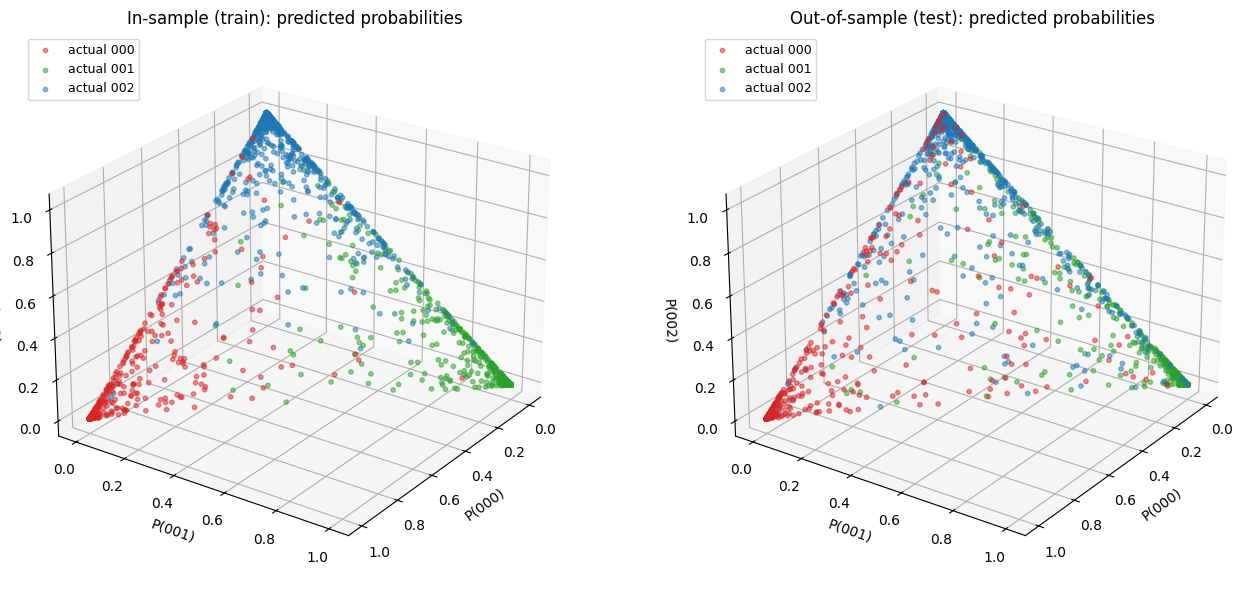

In [25]:
# Exercise #7: compute the associted predicted probabilities for each data point in both in-sample (train)
# and out-of-sample (test) datasets (use the "predict_proba" method for obtaining prediciton probabilities).
# Generate two three-dimensional scatter plots (one for each dataset) showing the predicted probabilities
# for each data point, and color each data point according to its actual category: 000, 001, or 002.

# add your code here...
from mpl_toolkits.mplot3d import Axes3D   # enables projection='3d'

# predicted probabilities for both datasets (one column per class, rows sum to 1)
trn_prob = logreg.predict_proba(trn_feat)
tst_prob = logreg.predict_proba(tst_feat)

classes = logreg.classes_            # column order of predict_proba: ['000','001','002']
colors  = {'000':'tab:red', '001':'tab:green', '002':'tab:blue'}

fig = plt.figure(figsize=(14,6))
for k, (prob, trgt, name) in enumerate([(trn_prob, trn_trgt, 'In-sample (train)'),
                                        (tst_prob, tst_trgt, 'Out-of-sample (test)')]):
    ax = fig.add_subplot(1, 2, k+1, projection='3d')
    for c in classes:                                  # color by ACTUAL category
        sel = (trgt == c)
        ax.scatter(prob[sel,0], prob[sel,1], prob[sel,2],
                   s=10, alpha=0.5, c=colors[c], label=f'actual {c}')
    ax.set_xlabel('P(000)'); ax.set_ylabel('P(001)'); ax.set_zlabel('P(002)')
    ax.set_title(f'{name}: predicted probabilities')
    ax.view_init(elev=25, azim=35)
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()



In [ ]:
# What are your main observations from the genereated scatter plots? How are the points distributed in the
# three-dimensional probability space? Can you explain why?
# <The points don't fill the cube they lie on a TRIANGLE, because the probabilities must sum to 1, so every point sits on the plane P(000)+P(001)+P(002) = 1 (the 2-simplex). Within it they pile up at the three vertices: the softmax is exponential in the linear scores, so even a modest score gap saturates the probability toward 0 or 1, leaving few hedged points in the middle. The test panel shows the same geometry but messier more drift toward the interior and more points of one color near the WRONG vertex (confident errors). That is the 0.94 -> 0.86 accuracy gap made visible.    >

,in-sample error,out-of-sample error
max_features,,
100,0.1694,0.2229
200,0.0588,0.1389
300,0.0197,0.1220
400,0.0097,0.1055
500,0.0029,0.0887
600,0.0021,0.0799
700,0.0013,0.0753
800,0.0008,0.0719
900,0.0000,0.0665


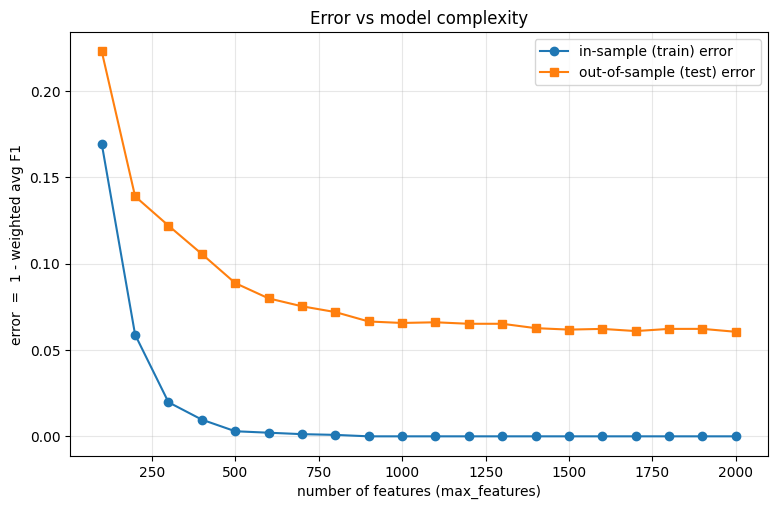

In [27]:
# Exercise #8: create a script to iterate over the number of features from 100 to 2000 (in 100 increments) and
# generate a plot displaying both the in-sample and out-of-sample errors versus the number of features. Use the
# "max_features" parameter of "CountVectorizer" to indicate the number of features at each iteration. Consider
# as error values: 1.0 - weigthwe_avg_F1-score.

# add your code here...
from sklearn.metrics import f1_score

nfeats, err_trn, err_tst = [], [], []

for nf in range(100, 2001, 100):
    # re-fit the vectorizer on the TRAIN text only, then apply it to the test text
    vectorizer = CountVectorizer(max_features=nf)
    trn_feat = vectorizer.fit_transform(trn_text)
    tst_feat = vectorizer.transform(tst_text)

    # retrain the model on the new feature set
    logreg = linear_model.LogisticRegression(max_iter=1000)
    logreg.fit(trn_feat, trn_trgt)

    # error = 1 - weighted average F1
    err_trn.append(1.0 - f1_score(trn_trgt, logreg.predict(trn_feat), average='weighted'))
    err_tst.append(1.0 - f1_score(tst_trgt, logreg.predict(tst_feat), average='weighted'))
    nfeats.append(nf)

# summary table, printed once after the loop
display(pd.DataFrame({'in-sample error': err_trn, 'out-of-sample error': err_tst},
                     index=pd.Index(nfeats, name='max_features')).round(4))

fig, ax = plt.subplots(figsize=(9,5.5))
ax.plot(nfeats, err_trn, 'o-', label='in-sample (train) error')
ax.plot(nfeats, err_tst, 's-', label='out-of-sample (test) error')
ax.set_xlabel('number of features (max_features)')
ax.set_ylabel('error  =  1 - weighted avg F1')
ax.set_title('Error vs model complexity')
ax.legend(); ax.grid(alpha=0.3)
plt.show()


In [ ]:
# What are your main observations from exercise #8? Do the error curves behave as you were expecting?
# Can you provide an explanation for the observed result?
# <The in-sample curve behaves as expected: it falls monotonically to ZERO by ~900 features, so past that point it says nothing about which model to pick. The out-of-sample curve drops steeply and then PLATEAUS at ~0.06 the classic U-shape (test error turning back up) never really appears, because sklearn's default L2 regularization shrinks the rare extra words toward zero and those words still carry a little authorial signal rather than pure noise. Practical read: ~900-1000 features is the sensible stopping point (doubling to 2000 buys only 0.005), and the plateau is an irreducible floor some paragraphs are simply ambiguous. The persistent GAP between the curves is the overfitting.    >

,in-sample error,out-of-sample error
train size,,
100,0.0000,0.3686
200,0.0050,0.3407
300,0.0302,0.3224
400,0.0601,0.3126
500,0.0721,0.2969
600,0.1022,0.2966
700,0.1090,0.2673
800,0.1190,0.2692
900,0.1270,0.2569


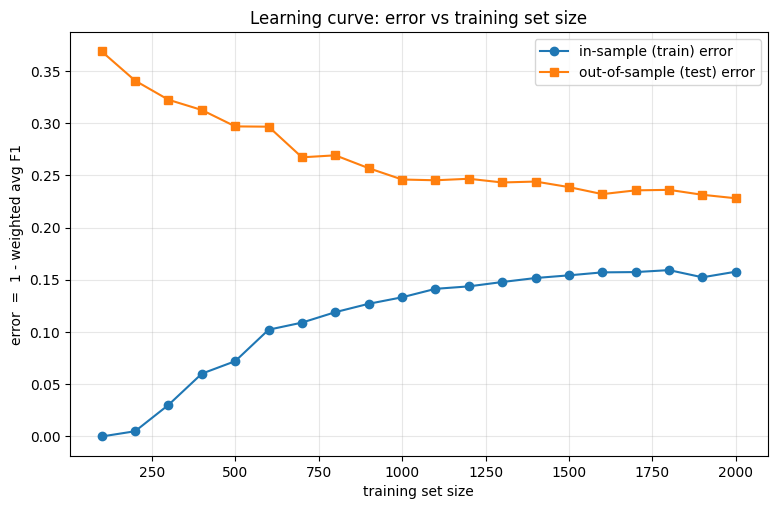

In [28]:
# Exercise #9: create a script to iterate over the in-sample (train) dataset size from 100 to 2000 (in 100
# increments) while keeping the out-of-sample dataset fixed and generate a plot displaying both the in-sample
# and out-of-sample errors versus the train data size. Set the "max_features" parameter of "CountVectorizer"
# to 100 for all iterations and, again, consider as error values: 1.0 - weigthwe_avg_F1-score.

# add your code here...
from sklearn.metrics import f1_score

# the out-of-sample set stays FIXED throughout
tst_text_fixed = test['tokenized_text'].values
tst_trgt_fixed = test['targets'].values

sizes, err_trn, err_tst = [], [], []

for n in range(100, 2001, 100):
    # take the first n paragraphs of the (already shuffled) train set
    sub      = train.iloc[:n]
    sub_text = sub['tokenized_text'].values
    sub_trgt = sub['targets'].values

    # vectorizer fitted on the training subsample only; 100 features at every iteration
    vectorizer = CountVectorizer(max_features=100)
    sub_feat = vectorizer.fit_transform(sub_text)
    tst_feat = vectorizer.transform(tst_text_fixed)

    logreg = linear_model.LogisticRegression(max_iter=1000)
    logreg.fit(sub_feat, sub_trgt)

    err_trn.append(1.0 - f1_score(sub_trgt, logreg.predict(sub_feat),
                                  average='weighted', zero_division=0))
    err_tst.append(1.0 - f1_score(tst_trgt_fixed, logreg.predict(tst_feat),
                                  average='weighted', zero_division=0))
    sizes.append(n)

display(pd.DataFrame({'in-sample error': err_trn, 'out-of-sample error': err_tst},
                     index=pd.Index(sizes, name='train size')).round(4))

fig, ax = plt.subplots(figsize=(9,5.5))
ax.plot(sizes, err_trn, 'o-', label='in-sample (train) error')
ax.plot(sizes, err_tst, 's-', label='out-of-sample (test) error')
ax.set_xlabel('training set size')
ax.set_ylabel('error  =  1 - weighted avg F1')
ax.set_title('Learning curve: error vs training set size')
ax.legend(); ax.grid(alpha=0.3)
plt.show()



In [ ]:
# What are your main observations from exercise #9? Do the error curves behave as you were expecting?
# Can you provide an explanation for the observed result?
# <Yes this is the classic learning curve, the mirror image of Ex.#8: with complexity fixed and data growing, the TRAIN error RISES (0.000 -> 0.158) while the TEST error FALLS (0.369 -> 0.228). The n = 100 point says it all: ~300 parameters on 100 paragraphs means p >> n, so the fit is PERFECT (error = 0) yet the test error is the WORST of the sweep pure memorization, and proof that the in-sample score is no estimate of generalization. The curves converge but flatten well above zero: that plateau is BIAS. Combined with Ex.#8 (where 900 features cut the test error to ~0.066), the model is data-saturated and feature-limited the bottleneck is capacity, not sample size. More vocabulary, not more paragraphs.     >

## PART 3: Classification with Naive Bayes

In [29]:
# loading required models
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import GaussianNB

In [30]:
# Exercise #10: consider a naive Bayes classifier (assuming multinomial distributions) for the three-book
# dataset from PART 2. Use the same in-sample/out-of-sampe data partition used before, train the classifier,
# apply the model to both data partitions and compute the corresponding evauation metrics. Note: you need
# to recompute the train and test features (which were modified in the previous exercise) by using the full
# in-sample (train) dataset. Use "max_features = 200" in "CountVectorizer" so your resuts here are comparable
# to those from exercise #6.

# add your code here...
from sklearn.naive_bayes import MultinomialNB

# rebuild the features from the FULL train set with 200 features (as in exercise #6),
# since exercise #9 overwrote them with subsamples
trn_text = train['tokenized_text'].values
tst_text = test['tokenized_text'].values
trn_trgt = train['targets'].values
tst_trgt = test['targets'].values

vectorizer = CountVectorizer(max_features=200)
trn_feat = vectorizer.fit_transform(trn_text)
tst_feat = vectorizer.transform(tst_text)

# train the multinomial naive Bayes classifier
nbayes = MultinomialNB()
nbayes.fit(trn_feat, trn_trgt)

# in-sample evaluation
trn_pdct = nbayes.predict(trn_feat)
print('\nIn-sample data evaluation scores:\n')
scores_trn_nb = classification_report(trn_trgt, trn_pdct)
print(scores_trn_nb)

# out-of-sample evaluation
tst_pdct = nbayes.predict(tst_feat)
print('\nOut-of-sample data evaluation scores:\n')
scores_tst_nb = classification_report(tst_trgt, tst_pdct)
print(scores_tst_nb)




In-sample data evaluation scores:

              precision    recall  f1-score   support

         000       0.86      0.92      0.89       626
         001       0.87      0.84      0.86       637
         002       0.89      0.88      0.89      1120

    accuracy                           0.88      2383
   macro avg       0.88      0.88      0.88      2383
weighted avg       0.88      0.88      0.88      2383


Out-of-sample data evaluation scores:

              precision    recall  f1-score   support

         000       0.85      0.88      0.87       616
         001       0.85      0.85      0.85       653
         002       0.88      0.86      0.87      1114

    accuracy                           0.86      2383
   macro avg       0.86      0.87      0.86      2383
weighted avg       0.86      0.86      0.86      2383



In [ ]:
# How your results from exercise #10 compare to those from exercise #6? What are your main conclusions?
# <Identical out-of-sample performance (0.86 both), but very different in-sample: Naive Bayes fits the training data worse (0.88 vs 0.94) yet generalizes just as well its train/test gap collapses from 8 points to 2. A textbook bias-variance contrast: NB's strong (and false) word-independence assumption is bias, so it can't chase the training data, but the same rigidity kills variance. LogReg's extra flexibility was spent entirely on noise. Conclusion: never rank models by their training score LogReg "wins" decisively in-sample yet ties out-of-sample, while NB is far cheaper to train.>

In [31]:
# Exercise #11: repeat exercise #10 but, in this case, assuming Bernoulli distributions

# add your code here...
from sklearn.naive_bayes import BernoulliNB

# same 200-feature representation as exercises #6 and #10 (trn_feat / tst_feat already built there)
bbayes = BernoulliNB()          # binarizes the counts internally: word present (1) vs absent (0)
bbayes.fit(trn_feat, trn_trgt)

# in-sample evaluation
trn_pdct = bbayes.predict(trn_feat)
print('\nIn-sample data evaluation scores:\n')
scores_trn_bnb = classification_report(trn_trgt, trn_pdct)
print(scores_trn_bnb)

# out-of-sample evaluation
tst_pdct = bbayes.predict(tst_feat)
print('\nOut-of-sample data evaluation scores:\n')
scores_tst_bnb = classification_report(tst_trgt, tst_pdct)
print(scores_tst_bnb)



In-sample data evaluation scores:

              precision    recall  f1-score   support

         000       0.90      0.88      0.89       626
         001       0.87      0.82      0.85       637
         002       0.86      0.90      0.88      1120

    accuracy                           0.87      2383
   macro avg       0.88      0.87      0.87      2383
weighted avg       0.87      0.87      0.87      2383


Out-of-sample data evaluation scores:

              precision    recall  f1-score   support

         000       0.87      0.82      0.84       616
         001       0.84      0.82      0.83       653
         002       0.84      0.89      0.86      1114

    accuracy                           0.85      2383
   macro avg       0.85      0.84      0.85      2383
weighted avg       0.85      0.85      0.85      2383



In [ ]:
# How your results from exercise #11 compare to those from exercise #10? What are your main conclusions?
# <Bernoulli is slightly worse than multinomial (0.85 vs 0.86 out-of-sample, and lower on every class), with the same tiny 0.02 gap both NB variants stay high-bias/low-variance, unlike LogReg's 0.08. The reason: BernoulliNB binarizes, asking only whether a word APPEARS, not how often. Since our 200 features are frequent function words present in nearly every paragraph, that discards exactly the frequency signal that is the authorial fingerprint. Lesson: the distributional assumption must match the feature representation. Best overall: MultinomialNB as accurate as LogReg, far cheaper, barely overfitting.   >

In [32]:
# Exercise #12: repeat exercise #11 but, in this case, assuming Gaussian distributions. Note: in this case
# you might need to convert the features from sparse to dense representations

# add your code here...
from sklearn.naive_bayes import GaussianNB

# GaussianNB does not accept sparse matrices -> convert to dense
trn_dense = trn_feat.toarray()
tst_dense = tst_feat.toarray()

gbayes = GaussianNB()
gbayes.fit(trn_dense, trn_trgt)

# in-sample evaluation
trn_pdct = gbayes.predict(trn_dense)
print('\nIn-sample data evaluation scores:\n')
scores_trn_gnb = classification_report(trn_trgt, trn_pdct)
print(scores_trn_gnb)

# out-of-sample evaluation
tst_pdct = gbayes.predict(tst_dense)
print('\nOut-of-sample data evaluation scores:\n')
scores_tst_gnb = classification_report(tst_trgt, tst_pdct)
print(scores_tst_gnb)




In-sample data evaluation scores:

              precision    recall  f1-score   support

         000       0.84      0.86      0.85       626
         001       0.66      0.98      0.79       637
         002       0.98      0.70      0.81      1120

    accuracy                           0.82      2383
   macro avg       0.83      0.85      0.82      2383
weighted avg       0.86      0.82      0.82      2383


Out-of-sample data evaluation scores:

              precision    recall  f1-score   support

         000       0.81      0.81      0.81       616
         001       0.63      0.97      0.76       653
         002       0.98      0.67      0.79      1114

    accuracy                           0.79      2383
   macro avg       0.80      0.81      0.79      2383
weighted avg       0.84      0.79      0.79      2383



In [ ]:
# How your results from exercise #12 compare to those from exercises #11 and #10? What are your main conclusions?
# <Gaussian is clearly the worst (0.79 out-of-sample vs 0.86 multinomial, 0.85 Bernoulli), and the per-class scores show the failure is worse than the accuracy suggests: class 001 has recall 0.97 but precision 0.63, class 002 the reverse it systematically dumps 002 paragraphs into 001. The reason: the Gaussian assumes continuous, symmetric, unbounded features, while word counts are non-negative integers that are mostly ZERO. Yet its train/test gap stays tiny (0.03), so it is not overfitting it fails through pure BIAS, from being the wrong model family.  >

,in-sample F1,out-of-sample F1
Logistic Reg. (#6),0.9412,0.8611
Multinomial NB (#10),0.8781,0.8641
Bernoulli NB (#11),0.8731,0.8486
Gaussian NB (#12),0.8171,0.7874


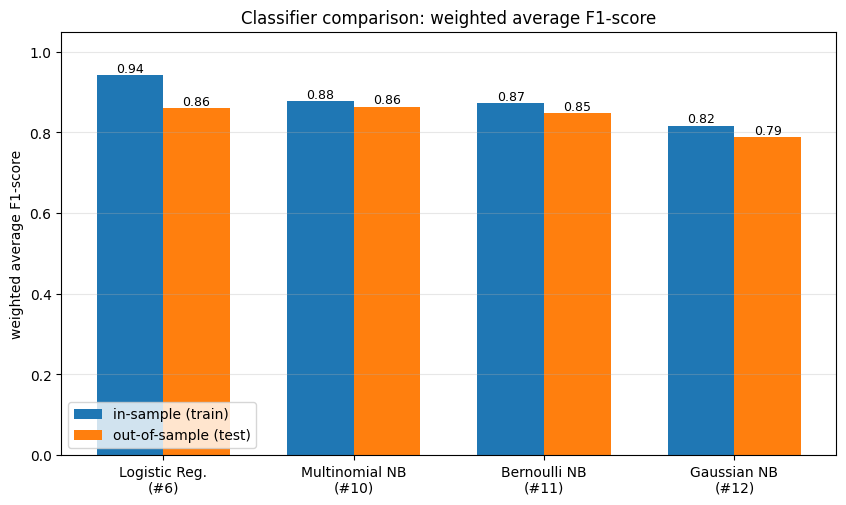

In [35]:
# Exercise #13: generate barplots comparing the weigthed average F1-scores for both in-sample (train) and
# out-of-sample (test) datasets among all different classifiers logistic regression (exercise #6), multinomial
# naive Bayes (exercise #10), Bernoulli naive Bayes (exercise #11), Gaussian naive Bayes (exercise #12)

# add your code here...
from sklearn.metrics import f1_score

# refit logistic regression on the CURRENT 200-feature matrices
# (the `logreg` in memory is the stale one from exercise #9's loop, fitted on 100 features)
logreg = linear_model.LogisticRegression(max_iter=1000)
logreg.fit(trn_feat, trn_trgt)

# each classifier with the feature matrices it needs (GaussianNB uses the dense ones)
models = {
    'Logistic Reg.\n(#6)'  : (logreg, trn_feat,  tst_feat),
    'Multinomial NB\n(#10)': (nbayes, trn_feat,  tst_feat),
    'Bernoulli NB\n(#11)'  : (bbayes, trn_feat,  tst_feat),
    'Gaussian NB\n(#12)'   : (gbayes, trn_dense, tst_dense),
}

names, f1_trn, f1_tst = [], [], []
for name, (mdl, Xtr, Xte) in models.items():
    names.append(name)
    f1_trn.append(f1_score(trn_trgt, mdl.predict(Xtr), average='weighted'))
    f1_tst.append(f1_score(tst_trgt, mdl.predict(Xte), average='weighted'))

display(pd.DataFrame({'in-sample F1': f1_trn, 'out-of-sample F1': f1_tst},
                     index=[n.replace('\n',' ') for n in names]).round(4))

x, w = np.arange(len(names)), 0.35
fig, ax = plt.subplots(figsize=(10,5.5))
b1 = ax.bar(x - w/2, f1_trn, w, label='in-sample (train)')
b2 = ax.bar(x + w/2, f1_tst, w, label='out-of-sample (test)')
ax.bar_label(b1, fmt='%.2f', fontsize=9)
ax.bar_label(b2, fmt='%.2f', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('weighted average F1-score')
ax.set_title('Classifier comparison: weighted average F1-score')
ax.set_ylim(0, 1.05); ax.legend(loc='lower left'); ax.grid(axis='y', alpha=0.3)
plt.show()


In [ ]:
# What are your main conclusions?
# <The blue orange GAP is overfitting, and only LogReg's bars are lopsided (0.94 -> 0.86) while the NB pairs are nearly level. Crucially, the in-sample ranking is WRONG it crowns LogReg by a mile, yet out-of-sample MultinomialNB nominally leads (0.864 vs 0.861, effectively a tie) while being far cheaper and barely overfitting. Gaussian NB loses on both partitions: wrong model family for sparse word counts, failing through bias, not variance. Never select a model on training scores.    >